# Packages

In [ ]:
import pandas as pd
from ISLP import load_data
import matplotlib.pyplot as plt
from ISLP.models import (ModelSpec as MS, summarize)
import statsmodels.api as sm
import seaborn as sns
import numpy as np

# Importation des données

In [2]:
Auto = load_data("Auto")

## a) Scatterplot matrix

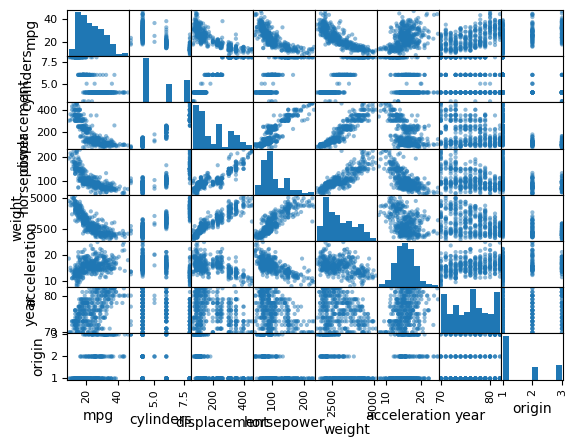

In [3]:
pd.plotting.scatter_matrix(Auto)
plt.show()

## b) Correlations

In [4]:
Auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


L'origine est le pays d'origine. La corrélation entre cette variable ne signifie pas grande chose.

## c) Regression

In [ ]:
X_list = list(Auto.columns.drop("mpg"))
X = MS(X_list).fit_transform(Auto)
Y = Auto["mpg"]

model = sm.OLS(Y, X)
result = model.fit()
#summarize(result)
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Sat, 20 Dec 2025   Prob (F-statistic):          2.04e-139
Time:                        10:43:47   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      -17.2184      4.644     -3.707   

### i)

Dans le test de Fisher, on teste l'hypothèse H0 selon laquelle tous les coefficients sont nuls. Vu que le p-value = 2.04e-139, nous avons des preuves rejetter H0. Ce qui veut dire qu'au moins une des variables explique "mpg".

### ii)

Les variables qui peuvent expliquer "mpg" sont : 
- displacement ; 
- weight ; 
- year ;
- origin. 

### iii)

Le coefficient lié à la variable "year" est égal à 0.75. Ce qui signifie qu'une voiture fabriquée une année après augmente le "mpg" de 0.75. Plus la voiture est récente, plus elle consomme moins de carburant. 

## d)

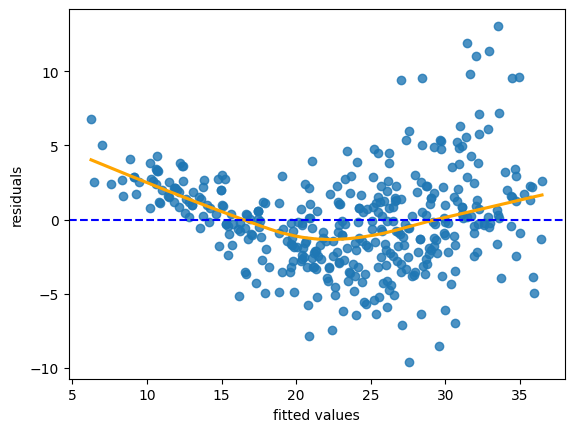

In [7]:
# Le modèle linéaire est-il approprié ?
sns.regplot(
    x=result.fittedvalues,
    y=result.resid,
    lowess=True,
    line_kws={"color": "orange"}
)

plt.axhline(0, color='b', linestyle='--')
plt.xlabel("fitted values")
plt.ylabel("residuals")
plt.show()

Comme on peut le voir, la ligne rouge correspond à un lissage des résidus. Elle présente une forme en U marquée, ce qui constitue une forte indication de non-linéarité dans les données. Ainsi, le modèle linéaire n'est le plus adapté pour ce problème. 

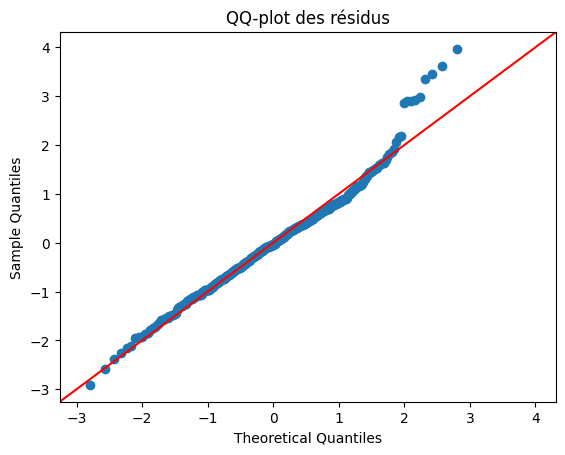

In [8]:
fig = sm.qqplot(
    result.resid,
    line='45',
    fit=True
)

plt.title("QQ-plot des résidus")
plt.show()

L'hypothèse de normalité des résidus tient la route.

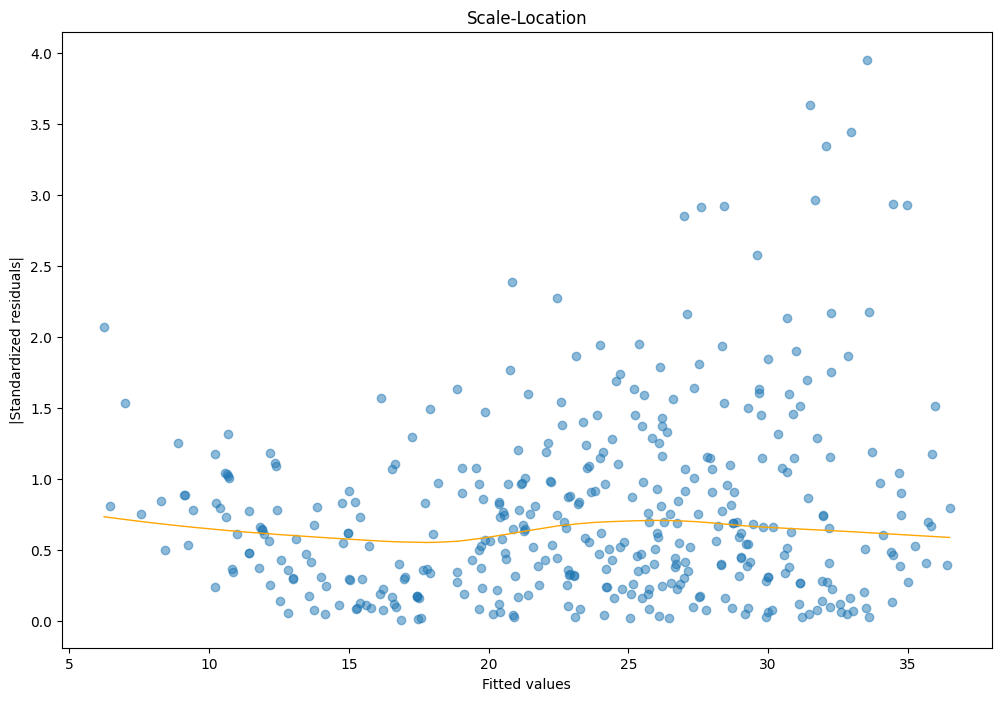

In [9]:
# La variance des résidus est-elle constante pour toutes les valeurs ajustées ? Sommes-nous en face de l'homoscédasticité? 

infl = result.get_influence()

# Résidus standardisés
r = infl.resid_studentized_internal

# Valeurs ajustées
fitted = result.fittedvalues

# Valeur absolue des résidus standardisés
abs_r = np.abs(r)

fig, ax = plt.subplots(figsize=(12, 8))

# Scatter
ax.scatter(fitted, abs_r, alpha=0.5)

# Lissage LOWESS
sns.regplot(
    x=fitted,
    y=abs_r,
    scatter=False,
    lowess=True,
    ci=False,
    line_kws=dict(color='orange', lw=1),
    ax=ax
)

ax.set(
    title="Scale-Location",
    xlabel="Fitted values",
    ylabel="|Standardized residuals|"
)

plt.show()

Aucune hétéroscédasticité marquée n’est observée, bien que quelques résidus plus élevés apparaissent pour les valeurs ajustées les plus grandes. On est dans l'hypothèse d'homoscédasticité. 

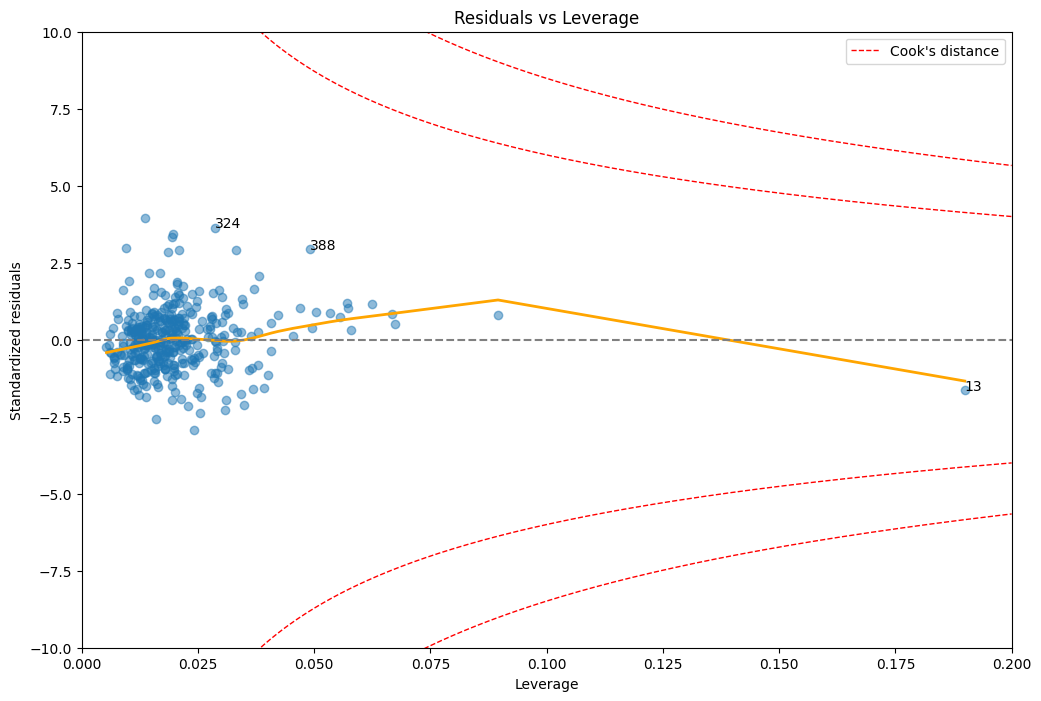

In [10]:
infl = result.get_influence()
r = infl.resid_studentized_internal
h = infl.hat_matrix_diag
D = infl.cooks_distance[0]
p = len(result.params)

fig, ax = plt.subplots(figsize=(12, 8))

# Scatter
ax.scatter(h, r, alpha=0.5)

# LOWESS (tendance) en ORANGE
sns.regplot(
    x=h, y=r,
    scatter=False,
    lowess=True,
    ci=False,
    line_kws=dict(color='orange', lw=2),
    ax=ax
)

# Ligne y = 0
ax.axhline(0, color='gray', ls='--')

# Courbes de Cook (pointillés rouges)
hh = np.linspace(0.01, 0.20, 300)
for d in (0.5, 1):
    y = np.sqrt((d * p * (1 - hh)) / hh)
    ax.plot(hh,  y, 'r--', lw=1, label="Cook's distance" if d == 0.5 else None)
    ax.plot(hh, -y, 'r--', lw=1)

# Annoter les points les plus influents
for i in np.argsort(D)[-3:]:
    ax.annotate(i, (h[i], r[i]))

# 🔍 Dézoom contrôlé
ax.set_xlim(0, 0.20)
ax.set_ylim(-10, 10)

ax.set(
    title="Residuals vs Leverage",
    xlabel="Leverage",
    ylabel="Standardized residuals"
)

ax.legend(loc='upper right')
plt.show()

Le leverage explique la contribution des observations dans la droite de régression. Les résidus standartisés mesurent la dispersion de la prédiction par rapport aux vraies valeurs d'une manière relative. Plus, ils sont grands, plus on s'approche d'un outlier.

Le point 13 est à haut leverage (0.19) contribue énormément à la droite de régression. Il y a aussi un deuxième point qui se situe entre 0.075 et 0.1 leverage. 

On s'aperçoit aussi la présence de certains outliers qui s'écartent de l'interval [-2.5 ; 2.5] des résidus standartisés.

# e) Model with interactions

Essayons de voir si l'accélération impacte significativement l'effet de la puissance sur mpg et que çà rend significatif l'impact de l'une ou l'autre variable indépendamment. 

In [11]:
Auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')

In [16]:
cols = list(Auto.columns.drop("mpg"))

In [17]:
X = MS(cols + [('horsepower', 'acceleration')]).fit_transform(Auto)
model = sm.OLS(Y, X)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     253.2
Date:                Sat, 20 Dec 2025   Prob (F-statistic):          8.74e-148
Time:                        10:44:58   Log-Likelihood:                -1000.8
No. Observations:                 392   AIC:                             2020.
Df Residuals:                     383   BIC:                             2055.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
intercept                 

L'interraction entre horsepower et acceleration est nettement significative.

Le souci c'est qu'elle absorbe l'effet de "cylinders" et de "displacement". 

Essayons une autre interraction avec les variables déjà significatives au départ

In [18]:
X = MS(cols + [('weight', 'displacement')] + [('weight', 'year')]).fit_transform(Auto)
model = sm.OLS(Y, X)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     278.4
Date:                Sat, 20 Dec 2025   Prob (F-statistic):          8.34e-162
Time:                        10:51:44   Log-Likelihood:                -964.70
No. Observations:                 392   AIC:                             1949.
Df Residuals:                     382   BIC:                             1989.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept             -72.4261    

On voit qu'avec une bonne spécification, le modèle est significatif au niveau global.  Nous avons pu aussi rendre significatif l'effet de "horsepower". 

### (f) : different transformations

Nous avons trouvé que notre régression linéaire souffre de la linéarité. Ainsi, nous voulons testé si avec une transformation, nous pouvons avoir les résidus comme linéaire.

#### (f1) : modification

In [22]:
horsepower = Auto["horsepower"]
horsepower_log = np.log10(Auto["horsepower"])
horsepower_sqrt = np.sqrt(Auto["horsepower"])

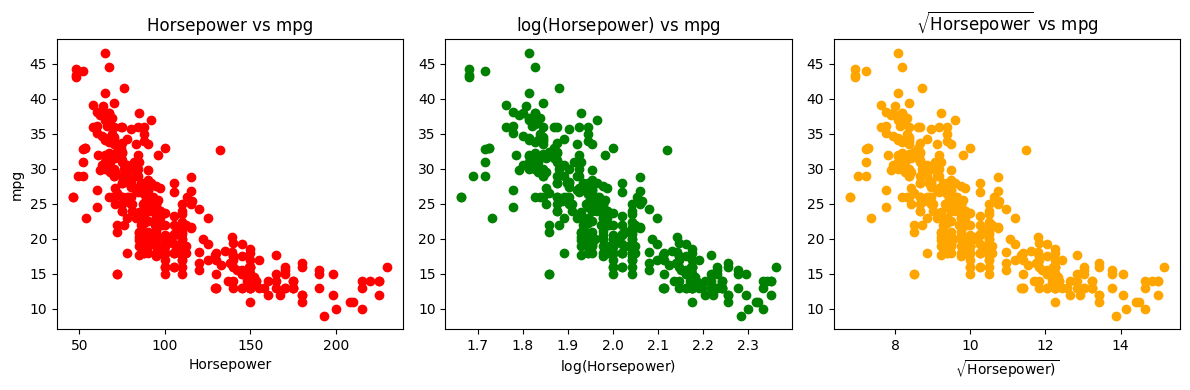

In [47]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].scatter(x=horsepower, y=Y, color='red')
axs[0].set_title('Horsepower vs mpg')
axs[0].set(xlabel='Horsepower', ylabel='mpg')

axs[1].scatter(x=horsepower_log, y=Y, color='green')
axs[1].set_title(r'$\log(\mathrm{Horsepower})$ vs mpg')
axs[1].set(xlabel=r'$\log(\mathrm{Horsepower})$')

axs[2].scatter(x=horsepower_sqrt, y=Y, color='orange')
axs[2].set_title(r'$\sqrt{\mathrm{Horsepower}}$ vs mpg')
axs[2].set(xlabel=r'$\sqrt{\mathrm{Horsepower})}$')

plt.tight_layout()
plt.show()

On constate que la relation reste en forme de curve après transformations. Cependant, on s'aperçoit que la transformation logarithmique s'approche un peu de la linéarité.

Essayons alors d'appliquer les mêmes transformations sur la variable cible si la relation est devenue hyper linéaire. 

In [54]:
Y = Y
Y_log = np.log10(Y)
Y_sqrt = np.sqrt(Y)

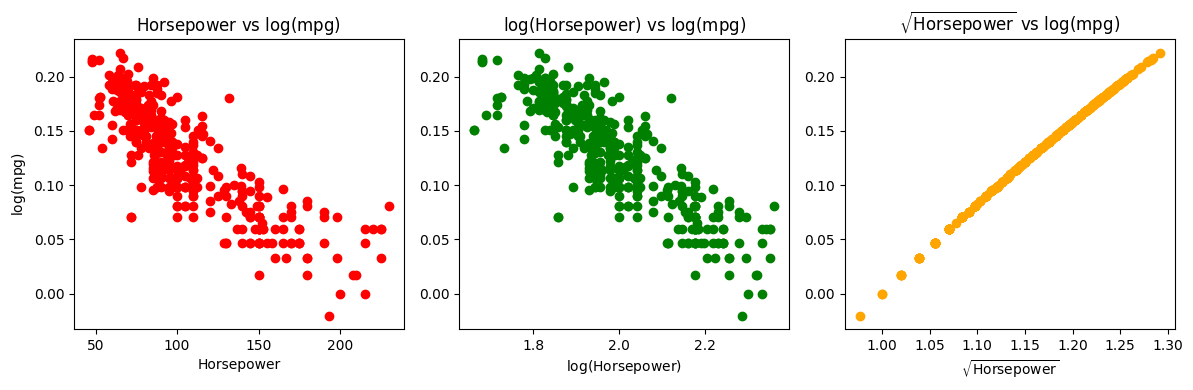

In [53]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].scatter(x=horsepower, y=Y_log, color='red')
axs[0].set_title(r'Horsepower vs $\log(\mathrm{mpg})$')
axs[0].set(xlabel='Horsepower', ylabel=r'$\log(\mathrm{mpg})$')

axs[1].scatter(x=horsepower_log, y=Y_log, color='green')
axs[1].set_title(r'$\log(\mathrm{Horsepower})$ vs $\log(\mathrm{mpg})$')
axs[1].set(xlabel=r'$\log(\mathrm{Horsepower})$')

axs[2].scatter(x=horsepower_sqrt, y=Y_log, color='orange')
axs[2].set_title(r'$\sqrt{\mathrm{Horsepower}}$ vs $\log(\mathrm{mpg})$')
axs[2].set(xlabel=r'$\sqrt{\mathrm{Horsepower}}$')

plt.tight_layout()
plt.show()

On voit maintenant que la relation est devenue quasi-linéaire surtout pour les deux variables transformées en log. La transformation avec sqrt( ) est cependant le plus linéaire.

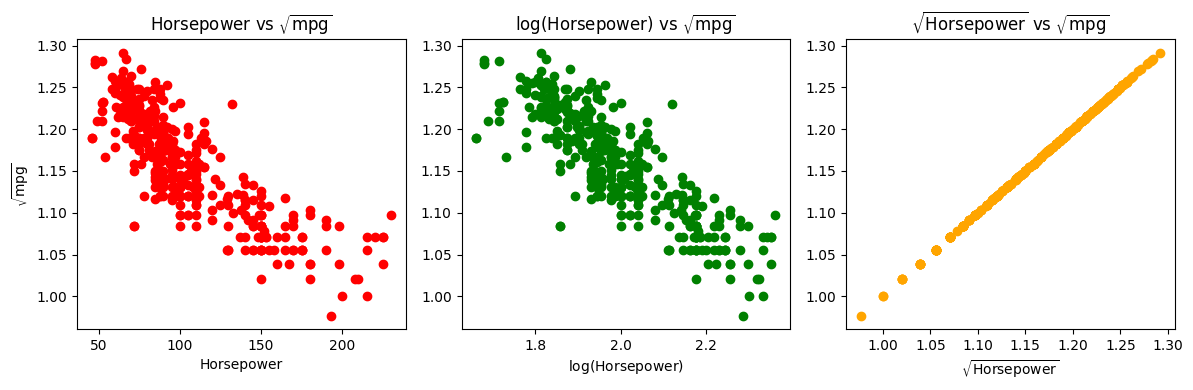

In [55]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].scatter(x=horsepower, y=Y_sqrt, color='red')
axs[0].set_title(r'Horsepower vs $\sqrt{\mathrm{mpg}}$')
axs[0].set(xlabel='Horsepower', ylabel=r'$\sqrt{\mathrm{mpg}}$')

axs[1].scatter(x=horsepower_log, y=Y_sqrt, color='green')
axs[1].set_title(r'$\log(\mathrm{Horsepower})$ vs $\sqrt{\mathrm{mpg}}$')
axs[1].set(xlabel=r'$\log(\mathrm{Horsepower})$')

axs[2].scatter(x=horsepower_sqrt, y=Y_sqrt, color='orange')
axs[2].set_title(r'$\sqrt{\mathrm{Horsepower}}$ vs $\sqrt{\mathrm{mpg}}$')
axs[2].set(xlabel=r'$\sqrt{\mathrm{Horsepower}}$')

plt.tight_layout()
plt.show()

On s'aperçoit donc que la meilleure transformation reste le graphique 2, shcéma 3.

Le schéma reste idéal, il est interprétable directement.

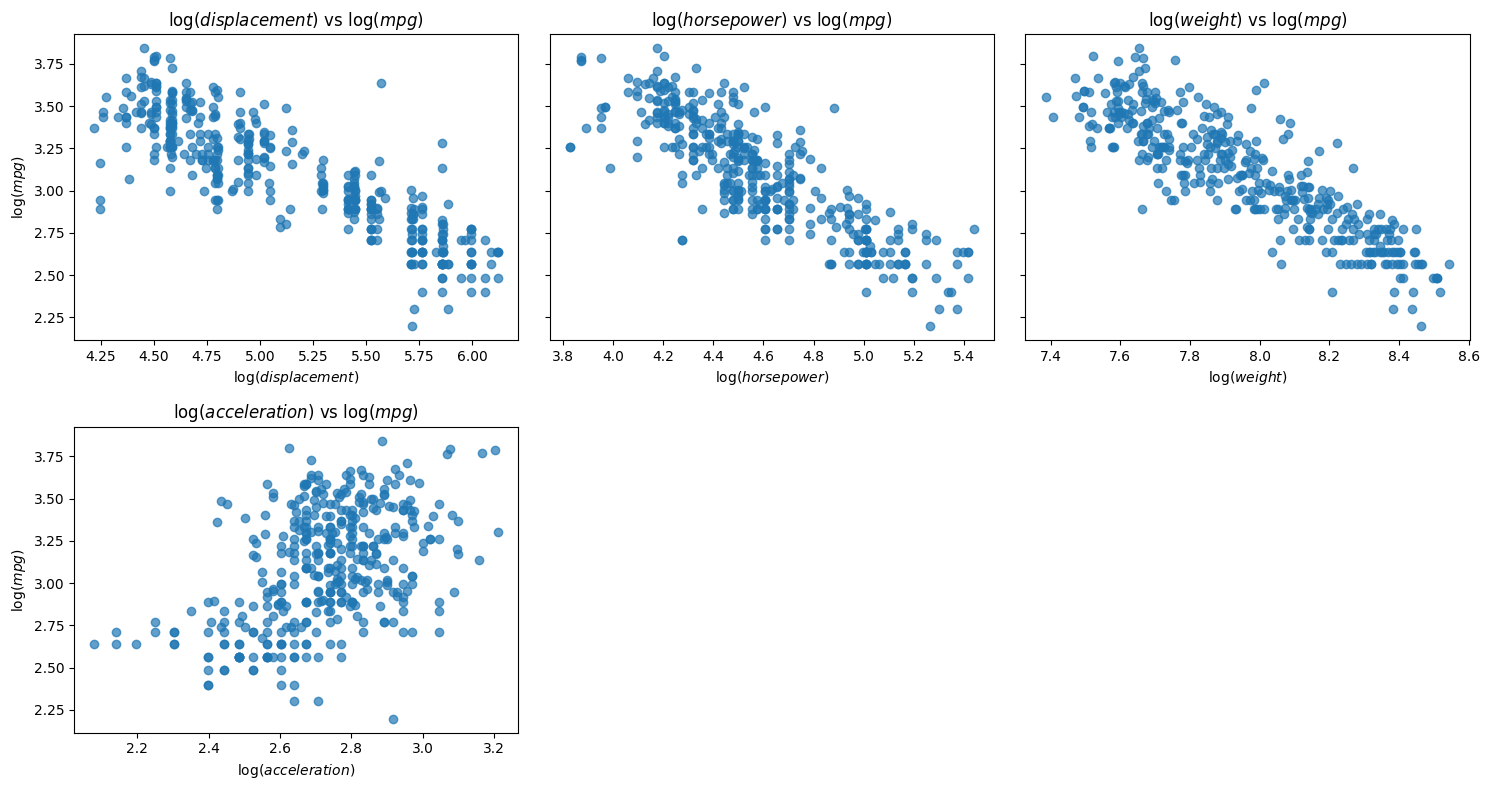

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import math

df = Auto

# Variables explicatives numériques (sauf mpg)
X_vars = df.select_dtypes(include="number").columns.drop("mpg")

# Exclure certaines variables
exclude = {"cylinders", "year", "origin"}
X_vars = [c for c in X_vars if c not in exclude]

# Réponse
Y_log = np.log(df["mpg"])

n = len(X_vars)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows), sharey=True)
axs = np.array(axs).reshape(-1)

for i, var in enumerate(X_vars):
    ax = axs[i]
    X = df[var]

    mask = (X > 0) & np.isfinite(X) & np.isfinite(Y_log)
    ax.scatter(np.log(X[mask]), Y_log[mask], alpha=0.7)

    ax.set_title(rf'$\log({var})$ vs $\log(mpg)$')
    ax.set_xlabel(rf'$\log({var})$')

    if i % ncols == 0:
        ax.set_ylabel(r'$\log(mpg)$')

# Désactiver les plots vides
for j in range(n, len(axs)):
    axs[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
df = Auto.copy()

# colonnes à exclure des transformations (mais à garder telles quelles)
no_transform = {"cylinders", "year", "origin", "displacement"}

# variables numériques explicatives à transformer (toutes sauf mpg et celles ci-dessus)
X_vars = df.select_dtypes(include="number").columns
X_to_transform = [c for c in X_vars if c not in ({"mpg"} | no_transform)]

# nouveau dataset
df_trans = pd.DataFrame(index=df.index)

# Y transformée
df_trans["log_mpg"] = np.log(df["mpg"])

# X transformées
for var in X_to_transform:
    df_trans[f"log_{var}"] = np.log(df[var])

# X non transformées (gardées)
for var in no_transform:
    df_trans[var] = df[var]

df_trans.head()

,log_mpg,log_horsepower,log_weight,log_acceleration,year,displacement,origin,cylinders
name,,,,,,,,
chevrolet chevelle malibu,2.890372,4.867534,8.161660,2.484907,70,307.0,1,8
buick skylark 320,2.708050,5.105945,8.214194,2.442347,70,350.0,1,8
plymouth satellite,2.890372,5.010635,8.142063,2.397895,70,318.0,1,8
amc rebel sst,2.772589,5.010635,8.141190,2.484907,70,304.0,1,8
ford torino,2.833213,4.941642,8.145840,2.351375,70,302.0,1,8


In [81]:
# Préparation à la modélisation
X_log = MS(df_trans.columns.drop("log_mpg")).fit_transform(df_trans)
Y_log = df_trans["log_mpg"]
print(X_log.head(), Y_log.head())

                           intercept  log_horsepower  log_weight  \
name                                                               
chevrolet chevelle malibu        1.0        4.867534    8.161660   
buick skylark 320                1.0        5.105945    8.214194   
plymouth satellite               1.0        5.010635    8.142063   
amc rebel sst                    1.0        5.010635    8.141190   
ford torino                      1.0        4.941642    8.145840   

                           log_acceleration  year  displacement  origin  \
name                                                                      
chevrolet chevelle malibu          2.484907    70         307.0       1   
buick skylark 320                  2.442347    70         350.0       1   
plymouth satellite                 2.397895    70         318.0       1   
amc rebel sst                      2.484907    70         304.0       1   
ford torino                        2.351375    70         302.0       1  

In [82]:
model_log = sm.OLS(Y_log, X_log)
result_log = model_log.fit()
print(result_log.summary())

                            OLS Regression Results                            
Dep. Variable:                log_mpg   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     451.3
Date:                Sat, 20 Dec 2025   Prob (F-statistic):          6.01e-181
Time:                        11:57:26   Log-Likelihood:                 302.67
No. Observations:                 392   AIC:                            -589.3
Df Residuals:                     384   BIC:                            -557.6
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
intercept            7.3889      0.403  

Nous avons perdu la relation avec displacement. Mais est-ce que le modèle capte une relation linéaire dans les résidus maintenant? 

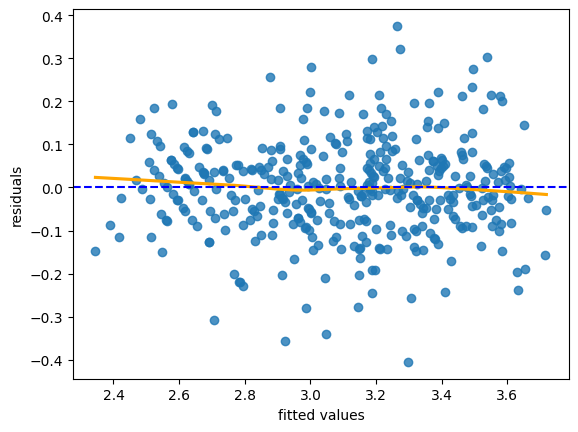

In [83]:
# Le modèle linéaire est-il approprié ?
sns.regplot(
    x=result_log.fittedvalues,
    y=result_log.resid,
    lowess=True,
    line_kws={"color": "orange"}
)

plt.axhline(0, color='b', linestyle='--')
plt.xlabel("fitted values")
plt.ylabel("residuals")
plt.show()

Le feature engineering a complètement changer les observations en linéaire, le modèle linéaire capte réellement les relations. 

Pour avoir un moèle linéaire acceptable, nous allons supprimer la variable displacement.

In [85]:
X_log["displacement"]

name
chevrolet chevelle malibu    307.0
buick skylark 320            350.0
plymouth satellite           318.0
amc rebel sst                304.0
ford torino                  302.0
                             ...  
ford mustang gl              140.0
vw pickup                     97.0
dodge rampage                135.0
ford ranger                  120.0
chevy s-10                   119.0
Name: displacement, Length: 392, dtype: float64

In [91]:
X_log_without_disp = X_log.drop("displacement", axis = 1)
model_log_without_disp = sm.OLS(Y_log, X_log_without_disp)
result_log_without_disp = model_log_without_disp.fit()
print(result_log_without_disp.summary())

                            OLS Regression Results                            
Dep. Variable:                log_mpg   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     526.2
Date:                Sat, 20 Dec 2025   Prob (F-statistic):          4.39e-182
Time:                        12:09:26   Log-Likelihood:                 302.10
No. Observations:                 392   AIC:                            -590.2
Df Residuals:                     385   BIC:                            -562.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
intercept            7.2002      0.361  

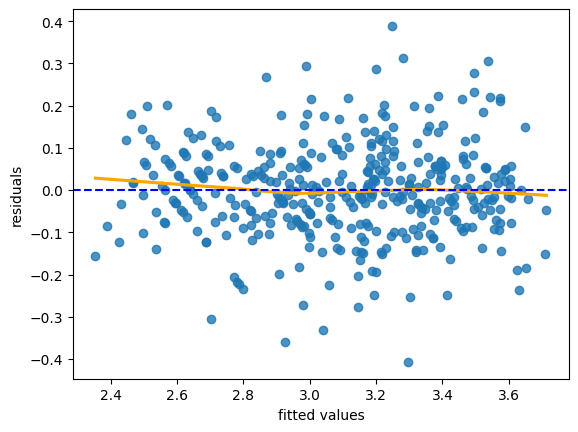

In [92]:
# Le modèle linéaire est-il approprié ?
sns.regplot(
    x=result_log_without_disp.fittedvalues,
    y=result_log_without_disp.resid,
    lowess=True,
    line_kws={"color": "orange"}
)

plt.axhline(0, color='b', linestyle='--')
plt.xlabel("fitted values")
plt.ylabel("residuals")
plt.show()

Tout est correct maintenant.

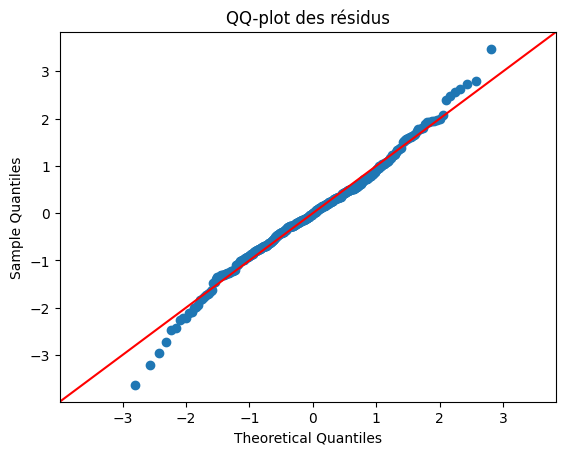

In [94]:
fig = sm.qqplot(
    result_log_without_disp.resid,
    line='45',
    fit=True
)

plt.title("QQ-plot des résidus")
plt.show()

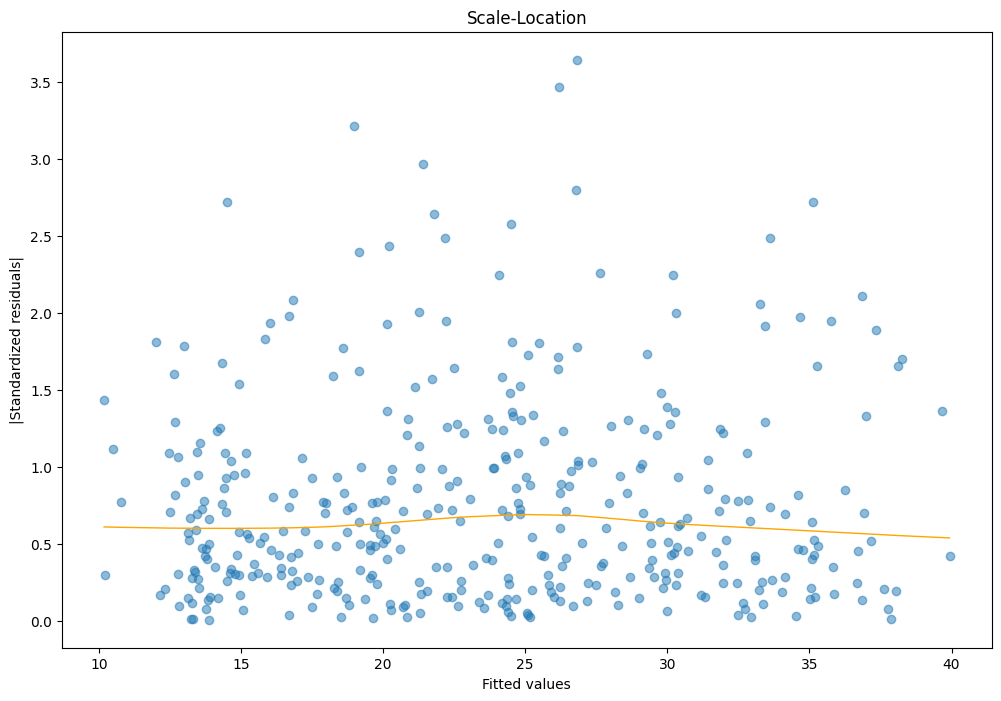

In [95]:
# La variance des résidus est-elle constante pour toutes les valeurs ajustées ? Sommes-nous en face de l'homoscédasticité? 

infl = result_log_without_disp.get_influence()

# Résidus standardisés
r = infl.resid_studentized_internal

# Valeurs ajustées
fitted = result.fittedvalues

# Valeur absolue des résidus standardisés
abs_r = np.abs(r)

fig, ax = plt.subplots(figsize=(12, 8))

# Scatter
ax.scatter(fitted, abs_r, alpha=0.5)

# Lissage LOWESS
sns.regplot(
    x=fitted,
    y=abs_r,
    scatter=False,
    lowess=True,
    ci=False,
    line_kws=dict(color='orange', lw=1),
    ax=ax
)

ax.set(
    title="Scale-Location",
    xlabel="Fitted values",
    ylabel="|Standardized residuals|"
)

plt.show()

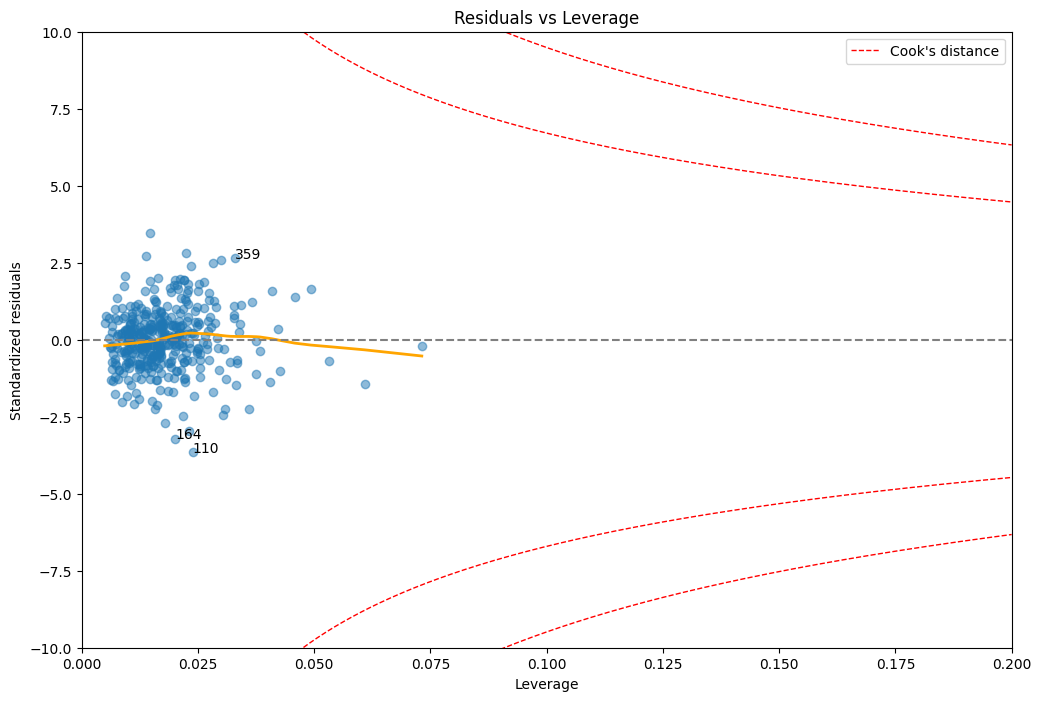

In [96]:
infl = result_log_without_disp.get_influence()
r = infl.resid_studentized_internal
h = infl.hat_matrix_diag
D = infl.cooks_distance[0]
p = len(result.params)

fig, ax = plt.subplots(figsize=(12, 8))

# Scatter
ax.scatter(h, r, alpha=0.5)

# LOWESS (tendance) en ORANGE
sns.regplot(
    x=h, y=r,
    scatter=False,
    lowess=True,
    ci=False,
    line_kws=dict(color='orange', lw=2),
    ax=ax
)

# Ligne y = 0
ax.axhline(0, color='gray', ls='--')

# Courbes de Cook (pointillés rouges)
hh = np.linspace(0.01, 0.20, 300)
for d in (0.5, 1):
    y = np.sqrt((d * p * (1 - hh)) / hh)
    ax.plot(hh,  y, 'r--', lw=1, label="Cook's distance" if d == 0.5 else None)
    ax.plot(hh, -y, 'r--', lw=1)

# Annoter les points les plus influents
for i in np.argsort(D)[-3:]:
    ax.annotate(i, (h[i], r[i]))

# 🔍 Dézoom contrôlé
ax.set_xlim(0, 0.20)
ax.set_ylim(-10, 10)

ax.set(
    title="Residuals vs Leverage",
    xlabel="Leverage",
    ylabel="Standardized residuals"
)

ax.legend(loc='upper right')
plt.show()

# Conclusion

- La relation entre les features et Y est maintenant linéaire, ce qui est bien capté par le modèle. 
- Modèle très explicatif (R²≈0.89) et globalement significatif (F-test).
- Toutes les variables sont significatives avec des variables clés : weight et horsepower (effets négatifs forts), year (effet positif net).
- Les résidus ne sont pas parfaitement normaux à cause des outliers.

La petite limite est la présence de quelques valeurs atypiques (outliers) et une possible multicolinéarité, ce qui peut rendre les coefficients moins stables et diminuer la fiabilité des prédictions pour des observations très éloignées de la plage d’apprentissage.